# From Self-Attention to Transformers: A Step-by-Step Tutorial
# STAT 426B - Section (Feb 24)

In HW3 we predicted **PM2.5** air pollution using RNN, LSTM, and GRU models. Today we solve the **same task** but replace the recurrent backbone with a **Transformer encoder**.

We will build every component from scratch so you can see exactly how attention works:

1. **Scaled Dot-Product Attention** - the core primitive  
2. **Multi-Head Attention** - running several attention heads in parallel  
3. **Positional Encoding** - injecting sequence order (Transformers have no built-in notion of position)  
4. **Transformer Encoder Block** - attention + feed-forward network + residual connections + layer norm  
5. **Full Transformer Forecaster** - stacking encoder blocks for time-series regression  

**Dataset**: Beijing Multi-Site Air Quality (Aotizhongxin station)  
**Task**: Given the past T=24 hours of 13 features, predict PM2.5 at hour t+1.

---
## Part 0 : Setup & Data Preprocessing (same as HW3)

We reuse the exact preprocessing pipeline from HW3 so the comparison is fair.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, time, warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

Using device: cpu


In [2]:
# ---------- Load & clean data (identical to HW3) ----------
df = pd.read_csv('PRSA_Data_Aotizhongxin_20130301-20170228.csv')
df_processed = df.copy()

numeric_cols = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']
df_processed[numeric_cols] = df_processed[numeric_cols].interpolate(method='linear', limit_direction='both')
df_processed['wd'] = df_processed['wd'].fillna(df_processed['wd'].mode()[0])

# Cyclical wind direction encoding
wind_map = {'N':0,'NNE':22.5,'NE':45,'ENE':67.5,'E':90,'ESE':112.5,'SE':135,'SSE':157.5,
            'S':180,'SSW':202.5,'SW':225,'WSW':247.5,'W':270,'WNW':292.5,'NW':315,'NNW':337.5}
df_processed['wd_rad'] = df_processed['wd'].map(wind_map) * np.pi / 180
df_processed['wd_sin'] = np.sin(df_processed['wd_rad'])
df_processed['wd_cos'] = np.cos(df_processed['wd_rad'])

feature_columns = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM','wd_sin','wd_cos']
data = df_processed[feature_columns].values
data = np.nan_to_num(data, nan=0.0)

print(f'Feature matrix: {data.shape}  ({len(feature_columns)} features)')

Feature matrix: (35064, 13)  (13 features)


In [3]:
# ---------- Chronological split & normalization ----------
n = len(data)
train_end = int(n * 0.8)
val_end   = int(n * 0.9)

scaler = StandardScaler()
train_scaled = scaler.fit_transform(data[:train_end])
val_scaled   = scaler.transform(data[train_end:val_end])
test_scaled  = scaler.transform(data[val_end:])

print(f'Train {train_scaled.shape}  Val {val_scaled.shape}  Test {test_scaled.shape}')

Train (28051, 13)  Val (3506, 13)  Test (3507, 13)


In [4]:
# ---------- Sliding-window dataset (T=24) ----------
PM25_IDX    = 0
WINDOW_SIZE = 24
BATCH_SIZE  = 64

def create_windows(data, target_idx, window):
    n = len(data) - window
    X = np.zeros((n, window, data.shape[1]))
    y = np.zeros(n)
    for i in range(n):
        X[i] = data[i:i+window]
        y[i] = data[i+window, target_idx]
    return X, y

X_train, y_train = create_windows(train_scaled, PM25_IDX, WINDOW_SIZE)
X_val,   y_val   = create_windows(val_scaled,   PM25_IDX, WINDOW_SIZE)
X_test,  y_test  = create_windows(test_scaled,  PM25_IDX, WINDOW_SIZE)

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.FloatTensor(X_val),   torch.FloatTensor(y_val)),
                          batch_size=BATCH_SIZE)
test_loader  = DataLoader(TensorDataset(torch.FloatTensor(X_test),  torch.FloatTensor(y_test)),
                          batch_size=BATCH_SIZE)

INPUT_DIM = X_train.shape[2]   # 13
print(f'Samples  -> Train {len(X_train)}  Val {len(X_val)}  Test {len(X_test)}')
print(f'Each sample: ({WINDOW_SIZE}, {INPUT_DIM}) -> 1 scalar')

Samples  -> Train 28027  Val 3482  Test 3483
Each sample: (24, 13) -> 1 scalar


In [5]:
# ---------- Metric helper ----------
def calc_metrics(y_true, y_pred, scaler=None, idx=0):
    """RMSE & MAE, optionally in original scale."""
    if scaler is not None:
        d = np.zeros((len(y_true), scaler.scale_.shape[0]))
        d[:, idx] = y_true
        y_true = scaler.inverse_transform(d)[:, idx]
        d[:, idx] = y_pred
        y_pred = scaler.inverse_transform(d)[:, idx]
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae  = np.mean(np.abs(y_true - y_pred))
    return rmse, mae

---
## Part 1 : Scaled Dot-Product Attention

The fundamental building block of the Transformer is **Scaled Dot-Product Attention** ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)).

Given a set of **queries** $Q$, **keys** $K$, and **values** $V$ (all matrices), attention computes:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V$$

**Intuition:**
- Each query asks: *"Which keys are most relevant to me?"*
- The dot product $QK^\top$ measures **similarity** between every query and every key.
- We divide by $\sqrt{d_k}$ to keep the dot products from growing too large (which would push softmax into regions with tiny gradients).
- Softmax turns similarities into **attention weights** (a probability distribution over positions).
- The output is a **weighted sum of values**, where the weights reflect relevance.

### Why is this different from an RNN?
An RNN processes tokens **one at a time**, passing information through a hidden state. Information from early tokens must survive many sequential steps to influence later predictions.

Attention computes **direct pairwise interactions** between all positions in parallel. Every position can attend to every other position in a single step -- no sequential bottleneck.

In [6]:
def scaled_dot_product_attention(Q, K, V):
    """
    Compute scaled dot-product attention.

    Args:
        Q: (batch, seq_len_q, d_k)   -- queries
        K: (batch, seq_len_k, d_k)   -- keys
        V: (batch, seq_len_k, d_v)   -- values

    Returns:
        output:  (batch, seq_len_q, d_v)
        weights: (batch, seq_len_q, seq_len_k)  -- attention weights
    """
    d_k = Q.size(-1)

    # Step 1: dot product between queries and keys
    scores = torch.matmul(Q, K.transpose(-2, -1))   # (B, T_q, T_k)

    # Step 2: scale
    scores = scores / math.sqrt(d_k)

    # Step 3: softmax -> attention weights
    weights = F.softmax(scores, dim=-1)              # (B, T_q, T_k)

    # Step 4: weighted sum of values
    output = torch.matmul(weights, V)                # (B, T_q, d_v)

    return output, weights

### Quick sanity check

Let's run a tiny example to see attention in action.

In [7]:
# Tiny example: batch=1, seq_len=4, d_k=d_v=8
torch.manual_seed(0)
Q_demo = torch.randn(1, 4, 8)
K_demo = torch.randn(1, 4, 8)
V_demo = torch.randn(1, 4, 8)

out_demo, attn_demo = scaled_dot_product_attention(Q_demo, K_demo, V_demo)

print('Attention weights (each row sums to 1):')
print(attn_demo.squeeze().detach().numpy().round(3))
print(f'\nRow sums: {attn_demo.squeeze().sum(dim=-1).detach().numpy().round(6)}')
print(f'Output shape: {out_demo.shape}  (batch=1, seq=4, d_v=8)')

Attention weights (each row sums to 1):
[[0.121 0.741 0.106 0.032]
 [0.258 0.265 0.171 0.307]
 [0.336 0.017 0.187 0.46 ]
 [0.203 0.623 0.102 0.071]]

Row sums: [1. 1. 1. 1.]
Output shape: torch.Size([1, 4, 8])  (batch=1, seq=4, d_v=8)


---
## Part 2 : Multi-Head Attention

A single attention head can only capture **one type** of relationship. Multi-head attention runs $h$ attention heads **in parallel**, each with its own learned projections, and then concatenates the results:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)\, W^O$$

where each head is:

$$\text{head}_i = \text{Attention}(Q W^Q_i,\; K W^K_i,\; V W^V_i)$$

- $W^Q_i, W^K_i \in \mathbb{R}^{d_{\text{model}} \times d_k}$, $W^V_i \in \mathbb{R}^{d_{\text{model}} \times d_v}$
- Typically $d_k = d_v = d_{\text{model}} / h$

**Why multiple heads?**  
Different heads can learn to focus on different aspects of the input. For our air quality data, one head might learn to attend to recent PM2.5 values (autocorrelation), while another attends to wind speed changes.

In [8]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Self-Attention (from scratch).

    Args:
        d_model:  model dimension (input & output size)
        n_heads:  number of attention heads
    """
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model must be divisible by n_heads'

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads   # dimension per head

        # Linear projections for Q, K, V and the final output
        self.W_q = nn.Linear(d_model, d_model)  # projects to ALL heads at once
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        """
        Self-attention: Q = K = V = x  (all come from the same sequence).

        x: (batch, seq_len, d_model)
        returns: (batch, seq_len, d_model), attention_weights
        """
        B, T, _ = x.shape

        # 1. Project to Q, K, V  --  shape: (B, T, d_model)
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # 2. Reshape into (B, n_heads, T, d_k)  so each head operates independently
        Q = Q.view(B, T, self.n_heads, self.d_k).transpose(1, 2)  # (B, h, T, d_k)
        K = K.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        # 3. Scaled dot-product attention (per head)
        attn_out, attn_weights = scaled_dot_product_attention(Q, K, V)
        # attn_out:     (B, h, T, d_k)
        # attn_weights: (B, h, T, T)

        # 4. Concatenate heads: (B, h, T, d_k) -> (B, T, d_model)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, self.d_model)

        # 5. Final linear projection
        output = self.W_o(attn_out)   # (B, T, d_model)

        return output, attn_weights

In [9]:
# Quick test
mha = MultiHeadAttention(d_model=64, n_heads=4)
x_test = torch.randn(2, 24, 64)   # batch=2, seq=24, d_model=64
out, weights = mha(x_test)
print(f'Input:   {x_test.shape}')
print(f'Output:  {out.shape}      (same shape -- residual-friendly)')
print(f'Weights: {weights.shape}   (B, heads, T, T)')

Input:   torch.Size([2, 24, 64])
Output:  torch.Size([2, 24, 64])      (same shape -- residual-friendly)
Weights: torch.Size([2, 4, 24, 24])   (B, heads, T, T)


---
## Part 3 : Positional Encoding

Self-attention is **permutation-equivariant**: if you shuffle the input tokens, the outputs get shuffled in the same way.  That means attention alone has **no notion of order**.

For time-series this is a problem -- the order of the 24 hours matters!  We fix this by adding a **positional encoding** to the input embeddings.

The original Transformer uses sinusoidal encodings:

$$PE_{(pos, 2i)}   = \sin\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

These are deterministic (no learnable parameters) and can generalize to unseen sequence lengths.

**Intuition:** Each dimension of the positional encoding oscillates at a different frequency.  Low-frequency dimensions distinguish far-apart positions; high-frequency dimensions distinguish nearby positions.  The model can learn to read these "clocks" to figure out where each token sits in the sequence.

In [10]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding (Vaswani et al., 2017).
    Added to the input embeddings so the model knows token order.
    """
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)             # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)   # even indices
        pe[:, 1::2] = torch.cos(position * div_term)   # odd indices
        pe = pe.unsqueeze(0)                            # (1, max_len, d_model)
        self.register_buffer('pe', pe)                  # not a learnable parameter

    def forward(self, x):
        """x: (batch, seq_len, d_model)"""
        return x + self.pe[:, :x.size(1), :]

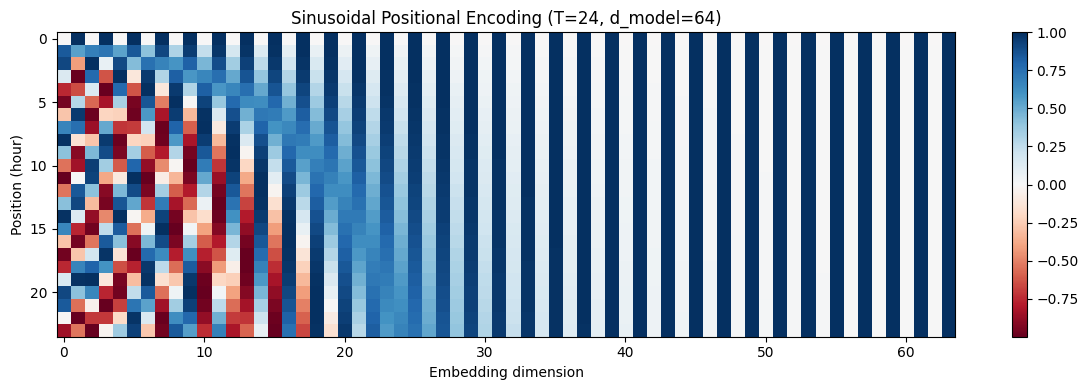

Low-frequency dimensions (right) vary slowly across positions.
High-frequency dimensions (left) vary rapidly.


In [11]:
# Visualize the positional encoding
pe_vis = PositionalEncoding(d_model=64, max_len=24)
pe_matrix = pe_vis.pe.squeeze().numpy()   # (24, 64)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pe_matrix, aspect='auto', cmap='RdBu')
ax.set_xlabel('Embedding dimension')
ax.set_ylabel('Position (hour)')
ax.set_title('Sinusoidal Positional Encoding (T=24, d_model=64)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print('Low-frequency dimensions (right) vary slowly across positions.')
print('High-frequency dimensions (left) vary rapidly.')

---
## Part 4 : Transformer Encoder Block

A single Transformer encoder block combines:

1. **Multi-Head Self-Attention** (the layer we just built)  
2. **Add & Norm** -- residual connection + layer normalization  
3. **Position-wise Feed-Forward Network (FFN)** -- two linear layers with ReLU  
4. **Add & Norm** again  

```
         x
         |
    +----+----+
    |  Multi-Head  |
    | Self-Attn    |
    +----+----+
         |  <-- residual: add x
    [ LayerNorm ]
         |
    +----+----+
    | Feed-Forward  |
    |   Network     |
    +----+----+
         |  <-- residual: add
    [ LayerNorm ]
         |
       output
```

### Why residual connections?
They let gradients flow directly through the network, enabling training of deep stacks.  Without them, stacking 6+ layers would cause vanishing gradients.

### Why layer normalization (not batch norm)?
Layer norm normalizes across the feature dimension **independently per sample**, making it robust to varying sequence lengths and small batch sizes.  It's the standard choice in Transformers.

In [12]:
class TransformerEncoderBlock(nn.Module):
    """
    A single Transformer encoder block.

    Components:
        1. Multi-Head Self-Attention
        2. Residual + LayerNorm
        3. Feed-Forward Network (2 linear layers with ReLU)
        4. Residual + LayerNorm
    """
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()

        # Sub-layer 1: Multi-Head Attention
        self.attention = MultiHeadAttention(d_model, n_heads)
        self.norm1     = nn.LayerNorm(d_model)
        self.dropout1  = nn.Dropout(dropout)

        # Sub-layer 2: Position-wise Feed-Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.norm2    = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (batch, seq_len, d_model)
        returns: (batch, seq_len, d_model)
        """
        # ---- Attention sub-layer ----
        attn_out, attn_weights = self.attention(x)
        x = self.norm1(x + self.dropout1(attn_out))     # residual + norm

        # ---- FFN sub-layer ----
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))      # residual + norm

        return x, attn_weights

In [13]:
# Test a single encoder block
block = TransformerEncoderBlock(d_model=64, n_heads=4, d_ff=128)
x_test = torch.randn(2, 24, 64)
out, w = block(x_test)
print(f'Encoder block: {x_test.shape} -> {out.shape}  (shape preserved for stacking)')

Encoder block: torch.Size([2, 24, 64]) -> torch.Size([2, 24, 64])  (shape preserved for stacking)


---
## Part 5 : Full Transformer Forecaster

Now we assemble everything into a complete model for PM2.5 forecasting:

1. **Input projection**: Linear layer from 13 raw features to `d_model`  
2. **Positional encoding**: Add position information  
3. **N encoder blocks**: Stack of Transformer encoder blocks  
4. **Pooling**: Average the output across all 24 time steps ("global average pooling over sequence")  
5. **Regression head**: Linear layer to predict a single PM2.5 value  

This is an **encoder-only** Transformer (like BERT), since we're doing regression, not sequence-to-sequence generation.

In [14]:
class TransformerForecaster(nn.Module):
    """
    Transformer encoder for time-series forecasting.

    Architecture:
        input (B, T, n_features)
          -> Linear projection to d_model
          -> Positional Encoding
          -> N x TransformerEncoderBlock
          -> Global Average Pooling over time
          -> Linear regression head -> scalar prediction
    """
    def __init__(self, n_features, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = PositionalEncoding(d_model)
        self.dropout    = nn.Dropout(dropout)

        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, x):
        """
        x: (batch, seq_len=24, n_features=13)
        returns: (batch,) predicted PM2.5
        """
        # 1. Project raw features to model dimension
        x = self.input_proj(x)       # (B, T, d_model)

        # 2. Add positional encoding
        x = self.pos_enc(x)
        x = self.dropout(x)

        # 3. Pass through encoder blocks
        attn_weights_all = []
        for block in self.encoder_blocks:
            x, w = block(x)
            attn_weights_all.append(w)

        # 4. Global average pooling over the time dimension
        x = x.mean(dim=1)            # (B, d_model)

        # 5. Regression head
        out = self.fc_out(x).squeeze(-1)  # (B,)

        return out, attn_weights_all

In [15]:
# Instantiate and inspect
model_cfg = dict(
    n_features = INPUT_DIM,   # 13
    d_model    = 64,
    n_heads    = 4,           # 64 / 4 = 16 per head
    d_ff       = 128,         # FFN hidden dim (typically 2-4x d_model)
    n_layers   = 2,           # number of encoder blocks
    dropout    = 0.1,
)

transformer_model = TransformerForecaster(**model_cfg).to(device)
n_params = sum(p.numel() for p in transformer_model.parameters())
print(f'TransformerForecaster')
print(f'  d_model={model_cfg["d_model"]}, heads={model_cfg["n_heads"]}, '
      f'FFN={model_cfg["d_ff"]}, layers={model_cfg["n_layers"]}')
print(f'  Total parameters: {n_params:,}')
print()
print(transformer_model)

TransformerForecaster
  d_model=64, heads=4, FFN=128, layers=2
  Total parameters: 67,905

TransformerForecaster(
  (input_proj): Linear(in_features=13, out_features=64, bias=True)
  (pos_enc): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder_blocks): ModuleList(
    (0-1): 2 x TransformerEncoderBlock(
      (attention): MultiHeadAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=True)
        (W_k): Linear(in_features=64, out_features=64, bias=True)
        (W_v): Linear(in_features=64, out_features=64, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
      (norm2): La

---
## Part 6 : Training the Transformer

We use the same training setup as HW3 (Adam optimizer, MSE loss, early stopping) for a fair comparison.

In [16]:
def train_model(model, train_loader, val_loader, num_epochs=50, lr=1e-3, patience=7):
    """
    Train with early stopping.  Works with models that return (pred, extras).
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    no_improve = 0
    epoch_times = []

    for epoch in range(num_epochs):
        # --- Train ---
        model.train()
        train_loss = 0.0
        t0 = time.time()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            out = model(bx)
            preds = out[0] if isinstance(out, tuple) else out
            loss = criterion(preds, by)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * bx.size(0)
        epoch_time = time.time() - t0
        epoch_times.append(epoch_time)
        train_loss /= len(train_loader.dataset)

        # --- Val ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                out = model(bx)
                preds = out[0] if isinstance(out, tuple) else out
                loss = criterion(preds, by)
                val_loss += loss.item() * bx.size(0)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:2d}/{num_epochs}]  '
                  f'Train Loss: {train_loss:.6f}  Val Loss: {val_loss:.6f}  ({epoch_time:.2f}s)')

        if no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

    if best_state:
        model.load_state_dict(best_state)
    avg_time = np.mean(epoch_times)
    print(f'Best val loss: {best_val_loss:.6f}  |  Avg epoch time: {avg_time:.2f}s')
    return history, avg_time

In [17]:
torch.manual_seed(42)
transformer_model = TransformerForecaster(**model_cfg).to(device)

print(f'Training TransformerForecaster  ({sum(p.numel() for p in transformer_model.parameters()):,} params)')
print('=' * 70)

tf_history, tf_epoch_time = train_model(
    transformer_model, train_loader, val_loader,
    num_epochs=50, lr=1e-3, patience=7
)

Training TransformerForecaster  (67,905 params)
Epoch [ 1/50]  Train Loss: 0.149142  Val Loss: 0.040870  (21.70s)
Epoch [ 5/50]  Train Loss: 0.087299  Val Loss: 0.031978  (29.31s)
Epoch [10/50]  Train Loss: 0.060821  Val Loss: 0.024938  (21.95s)
Epoch [15/50]  Train Loss: 0.061020  Val Loss: 0.023560  (21.12s)
Epoch [20/50]  Train Loss: 0.057597  Val Loss: 0.023205  (22.21s)

Early stopping at epoch 20
Best val loss: 0.021913  |  Avg epoch time: 22.61s


### Training Curves

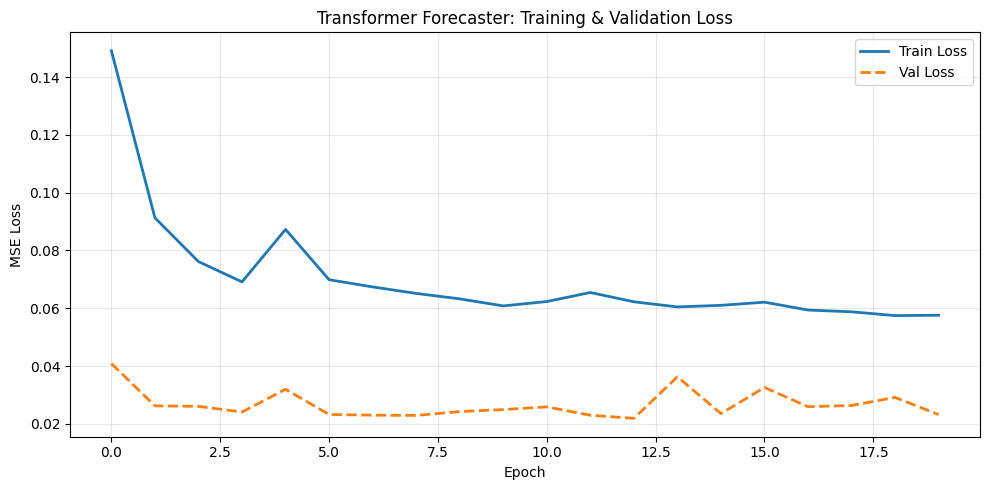

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tf_history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(tf_history['val_loss'],   label='Val Loss',   linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Transformer Forecaster: Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 7 : Evaluation & Comparison with HW3 Models

We compare the Transformer against the baselines and RNN variants from HW3.

In [19]:
# Evaluate Transformer on test set
transformer_model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for bx, by in test_loader:
        bx = bx.to(device)
        out = transformer_model(bx)
        preds = out[0] if isinstance(out, tuple) else out
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(by.numpy())

tf_preds   = np.array(all_preds)
tf_targets = np.array(all_targets)

tf_rmse, tf_mae = calc_metrics(tf_targets, tf_preds, scaler, PM25_IDX)
tf_rmse_n, tf_mae_n = calc_metrics(tf_targets, tf_preds)

print(f'Transformer (Test Set):')
print(f'  Normalized  - RMSE: {tf_rmse_n:.4f}, MAE: {tf_mae_n:.4f}')
print(f'  Original    - RMSE: {tf_rmse:.2f} ug/m3, MAE: {tf_mae:.2f} ug/m3')

Transformer (Test Set):
  Normalized  - RMSE: 0.2620, MAE: 0.1432
  Original    - RMSE: 21.36 ug/m3, MAE: 11.67 ug/m3


In [20]:
# ---------- Run the baselines for comparison ----------

# Persistence
y_persist = X_test[:, -1, PM25_IDX]
persist_rmse, persist_mae = calc_metrics(y_test, y_persist, scaler, PM25_IDX)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train.reshape(len(X_train), -1), y_train)
y_lr = lr_model.predict(X_test.reshape(len(X_test), -1))
lr_rmse, lr_mae = calc_metrics(y_test, y_lr, scaler, PM25_IDX)

print('Baselines recomputed for comparison.')

Baselines recomputed for comparison.


In [21]:
# ---------- Comparison table ----------
# HW3 reference numbers (from the solution notebook)
hw3_results = {
    'Vanilla RNN': {'rmse': 23.04, 'mae': 12.96, 'params': 13441},
    'LSTM':        {'rmse': 21.43, 'mae': 11.72, 'params': 53569},
    'GRU':         {'rmse': 22.74, 'mae': 13.03, 'params': 40193},
}

print('=' * 72)
print('FULL COMPARISON (Test Set, Original Scale ug/m3)')
print('=' * 72)
print(f'{"Model":<22} {"RMSE":>10} {"MAE":>10} {"Params":>12}')
print('-' * 72)
print(f'{"Persistence":<22} {persist_rmse:>10.2f} {persist_mae:>10.2f} {"--":>12}')
print(f'{"Linear Regression":<22} {lr_rmse:>10.2f} {lr_mae:>10.2f} {"--":>12}')
print('-' * 72)
for name, r in hw3_results.items():
    print(f'{name + " (HW3)":<22} {r["rmse"]:>10.2f} {r["mae"]:>10.2f} {r["params"]:>12,}')
print('-' * 72)
tf_params = sum(p.numel() for p in transformer_model.parameters())
print(f'{"Transformer (ours)":<22} {tf_rmse:>10.2f} {tf_mae:>10.2f} {tf_params:>12,}')
print('=' * 72)

FULL COMPARISON (Test Set, Original Scale ug/m3)
Model                        RMSE        MAE       Params
------------------------------------------------------------------------
Persistence                 23.61      12.44           --
Linear Regression           21.58      12.05           --
------------------------------------------------------------------------
Vanilla RNN (HW3)           23.04      12.96       13,441
LSTM (HW3)                  21.43      11.72       53,569
GRU (HW3)                   22.74      13.03       40,193
------------------------------------------------------------------------
Transformer (ours)          21.36      11.67       67,905


### Predicted vs. Actual (200-hour window)

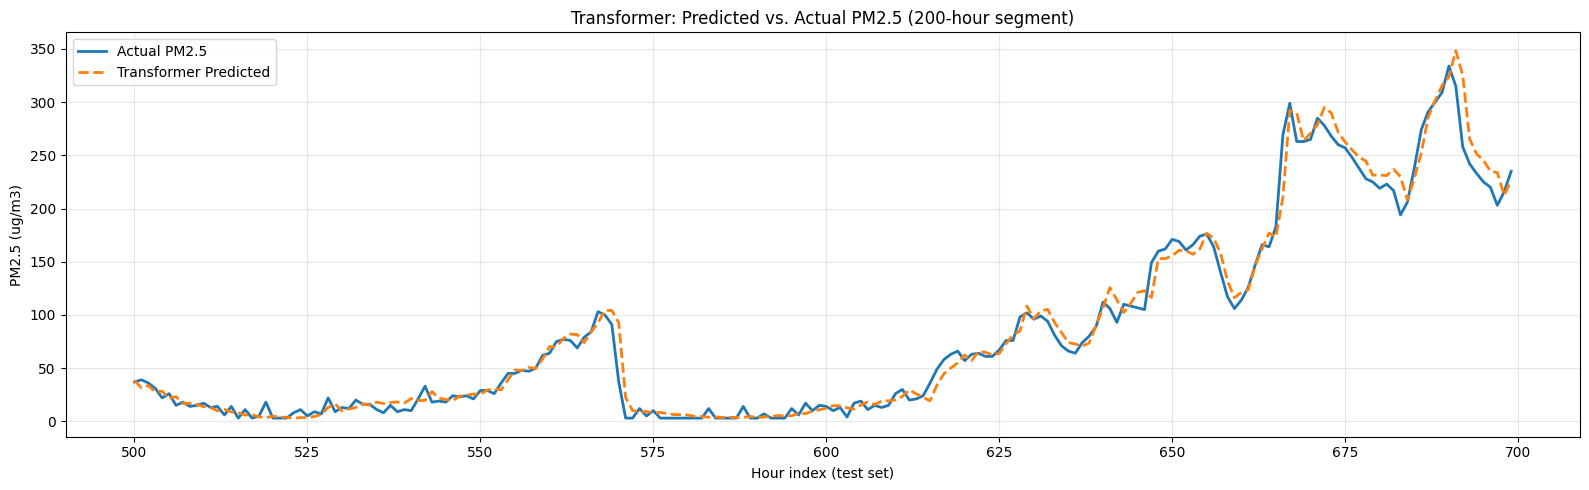

In [22]:
# Inverse-transform to original scale
n_f = scaler.scale_.shape[0]
d = np.zeros((len(tf_preds), n_f)); d[:, PM25_IDX] = tf_preds
preds_orig = scaler.inverse_transform(d)[:, PM25_IDX]
d[:, PM25_IDX] = tf_targets
targets_orig = scaler.inverse_transform(d)[:, PM25_IDX]

start, end = 500, 700
fig, ax = plt.subplots(figsize=(16, 5))
hours = np.arange(start, end)
ax.plot(hours, targets_orig[start:end], label='Actual PM2.5', linewidth=2)
ax.plot(hours, preds_orig[start:end],   label='Transformer Predicted', linewidth=2, linestyle='--')
ax.set_xlabel('Hour index (test set)')
ax.set_ylabel('PM2.5 (ug/m3)')
ax.set_title('Transformer: Predicted vs. Actual PM2.5 (200-hour segment)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 8 : Visualizing Attention Weights

One advantage of attention-based models is **interpretability**: we can look at the attention weights to see which time steps the model considers most important when making a prediction.

Below we pick a single test sample and visualize the attention pattern for each head in the first encoder layer.

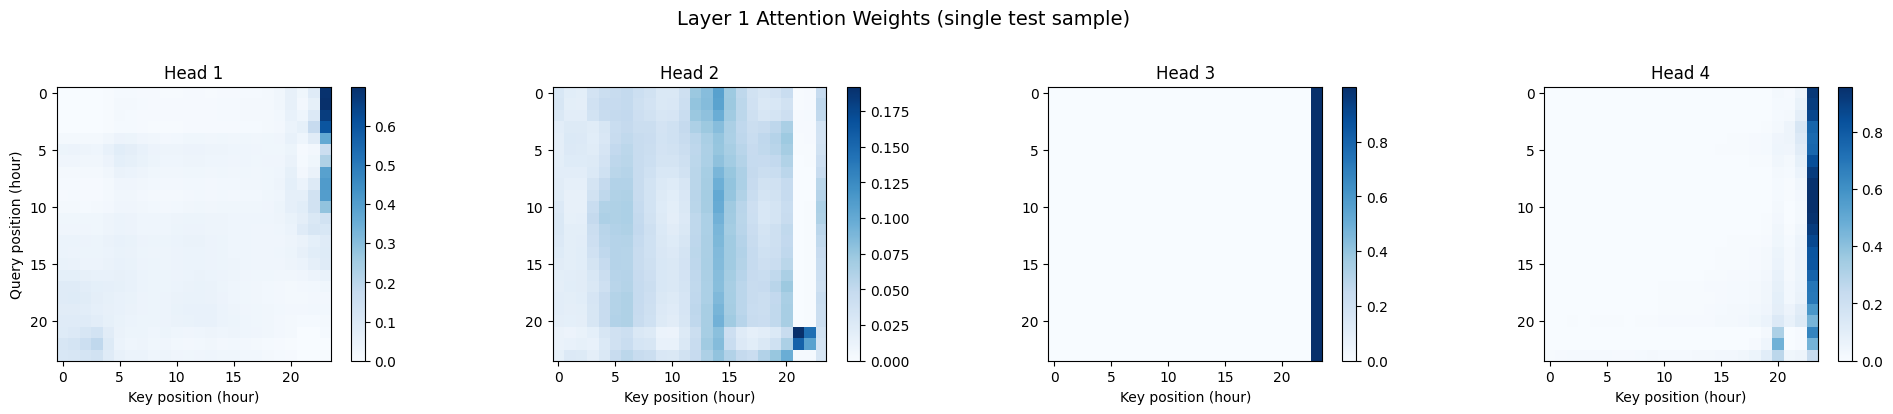

Each column shows how much attention a query (row) pays to each key (column).
Bright = high attention.  Different heads learn different patterns.


In [23]:
# Grab one sample and extract attention weights
transformer_model.eval()
sample_x = torch.FloatTensor(X_test[0:1]).to(device)  # (1, 24, 13)

with torch.no_grad():
    _, attn_list = transformer_model(sample_x)

# attn_list[layer_idx] has shape (1, n_heads, T, T)
layer0_attn = attn_list[0].squeeze(0).cpu().numpy()   # (n_heads, 24, 24)

n_heads = layer0_attn.shape[0]
fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 4))
for h in range(n_heads):
    ax = axes[h] if n_heads > 1 else axes
    im = ax.imshow(layer0_attn[h], cmap='Blues', vmin=0)
    ax.set_title(f'Head {h+1}')
    ax.set_xlabel('Key position (hour)')
    if h == 0:
        ax.set_ylabel('Query position (hour)')
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle('Layer 1 Attention Weights (single test sample)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Each column shows how much attention a query (row) pays to each key (column).')
print('Bright = high attention.  Different heads learn different patterns.')

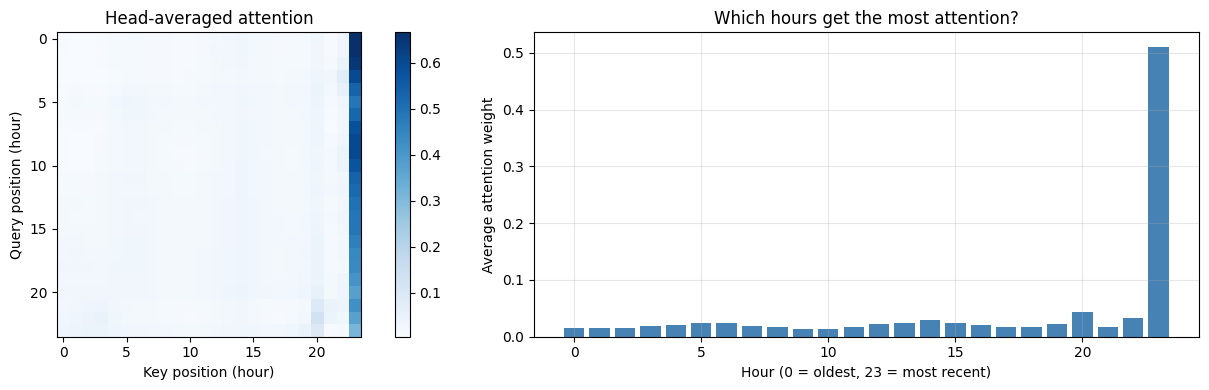

Top-3 attended hours: [23 20 22]  (0=24h ago, 23=1h ago)


In [24]:
# Average attention across heads -> which hours matter most overall?
avg_attn = layer0_attn.mean(axis=0)   # (24, 24)

# Average across query positions -> importance of each key position
key_importance = avg_attn.mean(axis=0)  # (24,)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

im = ax1.imshow(avg_attn, cmap='Blues')
ax1.set_xlabel('Key position (hour)')
ax1.set_ylabel('Query position (hour)')
ax1.set_title('Head-averaged attention')
plt.colorbar(im, ax=ax1)

ax2.bar(range(24), key_importance, color='steelblue')
ax2.set_xlabel('Hour (0 = oldest, 23 = most recent)')
ax2.set_ylabel('Average attention weight')
ax2.set_title('Which hours get the most attention?')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

top3 = np.argsort(key_importance)[-3:][::-1]
print(f'Top-3 attended hours: {top3}  (0=24h ago, 23=1h ago)')

---
## Part 9 : Recap -- How Self-Attention Becomes a Transformer

Let's summarize the journey from a single dot-product to a full Transformer:

| Layer | What it does | Why we need it |
|---|---|---|
| **Scaled Dot-Product Attention** | Computes weighted sum of values based on query-key similarity | Core mechanism: lets every position attend to every other position |
| **Multi-Head Attention** | Runs *h* parallel attention heads with separate learned projections | Captures diverse relationship types simultaneously |
| **Positional Encoding** | Adds sinusoidal signals to embeddings | Injects sequence order (attention is permutation-equivariant without it) |
| **Residual + LayerNorm** | Shortcut connections and per-sample normalization | Enables deep stacking; stabilizes training |
| **Feed-Forward Network** | Two linear layers with ReLU, applied position-wise | Adds nonlinear capacity beyond what attention alone provides |
| **Stacked Encoder Blocks** | Repeat the above *N* times | Builds hierarchical representations |

### Key Differences: Transformer vs. RNN/LSTM/GRU

| Property | RNN / LSTM / GRU | Transformer |
|---|---|---|
| **Sequence processing** | Sequential (one step at a time) | Parallel (all positions at once) |
| **Long-range dependencies** | Difficult (information must survive many steps) | Direct (any position attends to any other) |
| **Training parallelism** | Low (inherently sequential) | High (fully parallelizable) |
| **Position awareness** | Built-in (hidden state carries order) | Must be added (positional encoding) |
| **Complexity per layer** | O(T * d^2) | O(T^2 * d) -- quadratic in sequence length |
| **Interpretability** | Hidden state is opaque | Attention weights are inspectable |

For **short sequences** like our 24-hour window, the quadratic cost of attention is negligible and the ability to directly model all pairwise interactions is a clear win.

---
## Part 10 : Bonus -- Using `nn.TransformerEncoder` (PyTorch built-in)

In practice you don't need to write attention from scratch. PyTorch provides `nn.TransformerEncoderLayer` and `nn.TransformerEncoder`. Let's see how our from-scratch version compares to the built-in.

In [25]:
class TransformerForecasterBuiltIn(nn.Module):
    """Same architecture, but using PyTorch's built-in TransformerEncoder."""
    def __init__(self, n_features, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = PositionalEncoding(d_model)
        self.dropout    = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc_out  = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.dropout(self.pos_enc(self.input_proj(x)))
        x = self.encoder(x)          # (B, T, d_model)
        x = x.mean(dim=1)            # global average pool
        return self.fc_out(x).squeeze(-1)

builtin_model = TransformerForecasterBuiltIn(**model_cfg).to(device)
print(f'Built-in version params: {sum(p.numel() for p in builtin_model.parameters()):,}')
print(f'Our version params:      {sum(p.numel() for p in transformer_model.parameters()):,}')
print('\n(Small difference because PyTorch TransformerEncoderLayer uses slightly different LayerNorm placement.)')

Built-in version params: 67,905
Our version params:      67,905

(Small difference because PyTorch TransformerEncoderLayer uses slightly different LayerNorm placement.)


In [ ]:
torch.manual_seed(42)
builtin_model = TransformerForecasterBuiltIn(**model_cfg).to(device)

print('Training built-in TransformerForecaster')
print('=' * 70)

builtin_history, builtin_time = train_model(
    builtin_model, train_loader, val_loader,
    num_epochs=50, lr=1e-3, patience=7
)

Training built-in TransformerForecaster


In [ ]:
# Evaluate built-in model
builtin_model.eval()
bi_preds, bi_tgts = [], []
with torch.no_grad():
    for bx, by in test_loader:
        bx = bx.to(device)
        out = builtin_model(bx)
        bi_preds.extend(out.cpu().numpy())
        bi_tgts.extend(by.numpy())

bi_rmse, bi_mae = calc_metrics(np.array(bi_tgts), np.array(bi_preds), scaler, PM25_IDX)

print(f'Built-in Transformer (Test Set):')
print(f'  RMSE: {bi_rmse:.2f} ug/m3,  MAE: {bi_mae:.2f} ug/m3')
print(f'\nOur from-scratch Transformer (Test Set):')
print(f'  RMSE: {tf_rmse:.2f} ug/m3,  MAE: {tf_mae:.2f} ug/m3')
print(f'\nBoth should be in the same ballpark, confirming our implementation is correct.')

---
## Summary

In this tutorial we:

1. **Built self-attention from scratch**: scaled dot-product attention that computes pairwise similarity between all positions.

2. **Extended to multi-head attention**: running parallel attention heads to capture different relationship patterns.

3. **Added positional encoding**: sinusoidal signals that inject sequence order into an otherwise order-agnostic architecture.

4. **Assembled a Transformer encoder block**: attention + FFN + residual connections + layer normalization.

5. **Trained a full Transformer forecaster** on the same PM2.5 prediction task from HW3 and compared it against RNN/LSTM/GRU baselines.

6. **Visualized attention weights** to see which hours the model considers important.

7. **Verified our implementation** against PyTorch's built-in `nn.TransformerEncoder`.

### Key Takeaway
The Transformer replaces the sequential processing of RNNs with **parallel, global attention**. Each position can directly attend to every other position, eliminating the bottleneck of passing information through a chain of hidden states. This makes Transformers especially powerful for tasks where long-range dependencies matter.